## Level 3: Feature Analysis with Visuals

### Objective
To analyze the relationship between train journey features and journey duration using visualizations, correlation analysis, and a train-wise pivot table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Dataset1.csv")
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,00:00:00,06:00:00,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,08:08:00,08:10:00,199
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,09:19:00,09:21:00,312
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,12:38:00,12:40:00,577


In [5]:
df = df.sort_values(
    ["Train_No", "Route_Number", "SN"]
).reset_index(drop=True)
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
186069,8,99908,AKRD,195,176,157,138,AKURDI,1,23:30:00,23:31:00,19
186070,9,99908,DEHR,220,196,172,148,DEHU ROAD,1,23:35:00,23:36:00,24
186071,10,99908,BGWI,240,212,184,156,BEGDAEWAI,1,23:39:00,23:40:00,28
186072,11,99908,GRWD,255,224,193,162,GHORAWADI,1,23:41:00,23:42:00,31


In [7]:
df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],
    format="%H:%M:%S",
    errors="coerce"
)
df["Arrival_time"]

0        1900-01-01 00:00:00
1        1900-01-01 11:06:00
2        1900-01-01 11:28:00
3        1900-01-01 12:10:00
4        1900-01-01 00:00:00
                 ...        
186069   1900-01-01 23:30:00
186070   1900-01-01 23:35:00
186071   1900-01-01 23:39:00
186072   1900-01-01 23:41:00
186073   1900-01-01 23:50:00
Name: Arrival_time, Length: 186074, dtype: datetime64[ns]

In [8]:
df["Departure_Time"]

0        1900-01-01 10:25:00
1        1900-01-01 11:08:00
2        1900-01-01 11:30:00
3        1900-01-01 00:00:00
4        1900-01-01 20:30:00
                 ...        
186069   1900-01-01 23:31:00
186070   1900-01-01 23:36:00
186071   1900-01-01 23:40:00
186072   1900-01-01 23:42:00
186073   1900-01-01 00:00:00
Name: Departure_Time, Length: 186074, dtype: datetime64[ns]

In [10]:
train_journey = df.groupby("Train_No").agg(
    Start_Station=("Station_Name", "first"),
    End_Station=("Station_Name", "last"),
    Start_Time=("Departure_Time", "first"),
    End_Time=("Arrival_time", "last"),
    Total_Distance=("Distance", "max"),
    Number_of_Stops=("Station_Name", "count")
).reset_index()
train_journey.head(10)

,Train_No,Start_Station,End_Station,Start_Time,End_Time,Total_Distance,Number_of_Stops
0,107,SAWANTWADI R,MADGOAN JN.,1900-01-01 10:25:00,1900-01-01 12:10:00,78,4
1,108,MADGOAN JN.,SAWANTWADI R,1900-01-01 20:30:00,1900-01-01 22:25:00,83,4
2,128,MADGOAN JN.,CHHATRAPATI,1900-01-01 19:40:00,1900-01-01 17:45:00,978,22
3,290,DELHI-SAFDAR,DELHI-SAFDAR,1900-01-01 18:30:00,1900-01-01 02:30:00,2694,14
4,401,AURANGABAD,VARANASI JN.,1900-01-01 21:30:00,1900-01-01 10:00:00,1618,12
5,421,LUCKNOW JN.,SHRI MATA VA,1900-01-01 23:00:00,1900-01-01 08:00:00,1276,5
6,422,SHRI MATA VA,LUCKNOW JN.,1900-01-01 11:45:00,1900-01-01 14:30:00,1277,5
7,477,SIRSA,SIRSA,1900-01-01 12:10:00,1900-01-01 15:20:00,2616,14
8,502,RAJENDRANAGA,AMBALA CANTT,1900-01-01 10:30:00,1900-01-01 09:30:00,1206,9
9,504,PATNA JN.,BATHINDA JN,1900-01-01 09:00:00,1900-01-01 10:00:00,1313,3


In [11]:
train_journey["Journey_Duration"] = (
    train_journey["End_Time"] -
    train_journey["Start_Time"]
).dt.total_seconds() / 60

In [12]:
train_journey["Journey_Duration"]

0        105.0
1        115.0
2       -115.0
3       -960.0
4       -690.0
         ...  
11108     50.0
11109     43.0
11110     50.0
11111     52.0
11112     50.0
Name: Journey_Duration, Length: 11113, dtype: float64

In [13]:
train_journey.loc[
    train_journey["Journey_Duration"] < 0,
    "Journey_Duration"
] += 24 * 60

In [14]:
train_journey.head()

,Train_No,Start_Station,End_Station,Start_Time,End_Time,Total_Distance,Number_of_Stops,Journey_Duration
0,107,SAWANTWADI R,MADGOAN JN.,1900-01-01 10:25:00,1900-01-01 12:10:00,78,4,105.0
1,108,MADGOAN JN.,SAWANTWADI R,1900-01-01 20:30:00,1900-01-01 22:25:00,83,4,115.0
2,128,MADGOAN JN.,CHHATRAPATI,1900-01-01 19:40:00,1900-01-01 17:45:00,978,22,1325.0
3,290,DELHI-SAFDAR,DELHI-SAFDAR,1900-01-01 18:30:00,1900-01-01 02:30:00,2694,14,480.0
4,401,AURANGABAD,VARANASI JN.,1900-01-01 21:30:00,1900-01-01 10:00:00,1618,12,750.0


## Task 3.1: Distance vs Journey Duration

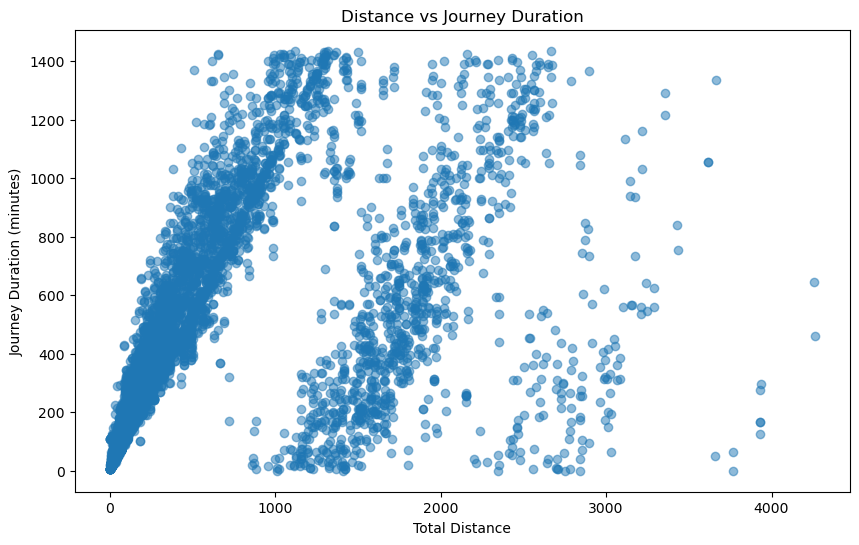

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_journey["Total_Distance"],
    train_journey["Journey_Duration"],
    alpha=0.5
)

plt.xlabel("Total Distance")
plt.ylabel("Journey Duration (minutes)")
plt.title("Distance vs Journey Duration")

plt.show()

## Task 3.2: Number of Stops vs Journey Duration

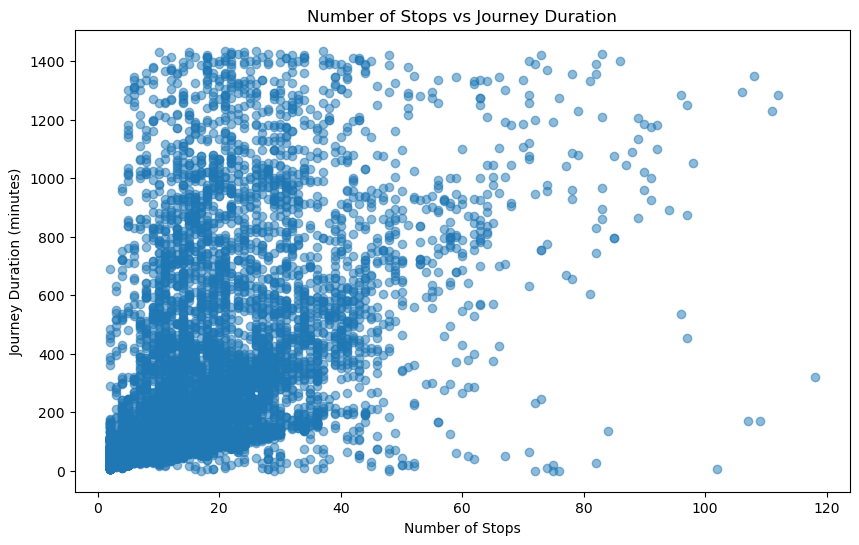

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_journey["Number_of_Stops"],
    train_journey["Journey_Duration"],
    alpha=0.5
)

plt.xlabel("Number of Stops")
plt.ylabel("Journey Duration (minutes)")
plt.title("Number of Stops vs Journey Duration")

plt.show()

## Task 3.3: Correlation Analysis

In [18]:
correlation_data = train_journey[
    [
        "Total_Distance",
        "Number_of_Stops",
        "Journey_Duration"
    ]
]
correlation_data.head()

,Total_Distance,Number_of_Stops,Journey_Duration
0,78,4,105.0
1,83,4,115.0
2,978,22,1325.0
3,2694,14,480.0
4,1618,12,750.0


In [19]:
correlation_matrix = correlation_data.corr()
correlation_matrix

,Total_Distance,Number_of_Stops,Journey_Duration
Total_Distance,1.000000,0.461854,0.635700
Number_of_Stops,0.461854,1.000000,0.500264
Journey_Duration,0.635700,0.500264,1.000000


In [20]:
import seaborn as sns

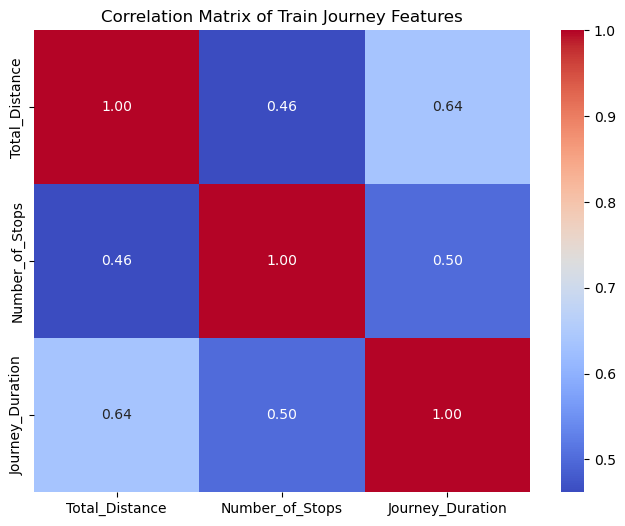

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Train Journey Features")
plt.show()

## Task 3.4: Train-wise Number of Stops Pivot Table

In [22]:
stops_pivot = pd.pivot_table(
    train_journey,
    index="Train_No",
    values="Number_of_Stops",
    aggfunc="sum"
)

In [23]:
stops_pivot.head()

,Number_of_Stops
Train_No,
107,4
108,4
128,22
290,14
401,12


In [24]:
print("Number of trains in pivot table:", len(stops_pivot))

Number of trains in pivot table: 11113


### Distribution of Number of Stops

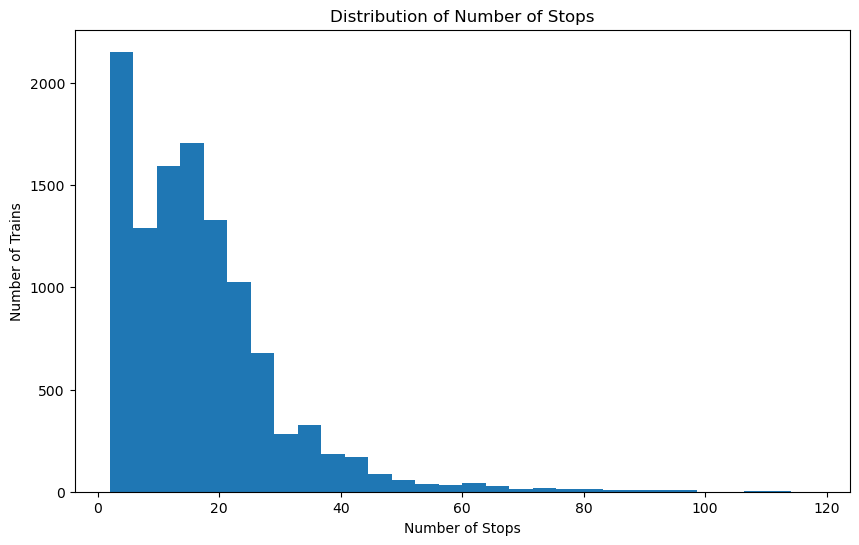

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_journey["Number_of_Stops"],
    bins=30
)

plt.xlabel("Number of Stops")
plt.ylabel("Number of Trains")
plt.title("Distribution of Number of Stops")

plt.show()

In [26]:
train_journey[
    [
        "Total_Distance",
        "Number_of_Stops",
        "Journey_Duration"
    ]
].describe()

,Total_Distance,Number_of_Stops,Journey_Duration
count,11113.000000,11113.000000,11113.000000
mean,348.870242,16.743814,276.013498
std,596.179751,12.993123,321.166943
min,1.000000,2.000000,0.000000
25%,38.000000,8.000000,61.000000
50%,82.000000,15.000000,132.000000
75%,324.000000,22.000000,365.000000
max,4260.000000,118.000000,1435.000000


In [27]:
correlation_matrix.to_csv(
    "level3_correlation_matrix.csv"
)

In [28]:
stops_pivot.to_csv(
    "level3_train_stops_pivot.csv"
)

In [29]:
train_journey.to_csv(
    "train_journey_level3.csv",
    index=False
)

## Level 3 Summary

The relationships between the main train journey features were analyzed using visualizations and correlation analysis.

The analysis included:
- Distance vs Journey Duration
- Number of Stops vs Journey Duration
- Correlation analysis between numerical features
- A correlation heatmap
- A train-wise pivot table for number of stops

These analyses help identify which features may be useful for predicting train journey duration.

The results from Level 3 will be used as a basis for selecting features and training machine learning models in Level 4.